# Super-Resolution: SRGAN & Real-ESRGAN with Comparison

## 1. Install & Imports

In [1]:
!pip install -q torchmetrics lpips

In [2]:
import os, math, random, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid
from torchvision.models import vgg19, VGG19_Weights

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Configuration

In [3]:
class Config:
    DATA_DIR      = '/kaggle/input/datasets/joe1995/div2k-dataset'
    HR_SIZE       = 120
    LR_SIZE       = 24
    VAL_RATIO     = 0.05

    EPOCHS        = 100
    BATCH_SIZE    = 8
    LR_G          = 1e-4
    LR_D          = 1e-4
    AMP           = True
    NUM_WORKERS   = 2
    VAL_EVERY     = 5

    LAMBDA_PIXEL  = 1.0
    LAMBDA_PERC   = 0.006
    LAMBDA_ADV    = 1e-3

    SAVE_DIR      = '/kaggle/working/checkpoints'
    SAMPLE_DIR    = '/kaggle/working/samples'
    SEED          = 42

cfg = Config()

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
torch.cuda.manual_seed_all(cfg.SEED)

os.makedirs(cfg.SAVE_DIR,  exist_ok=True)
os.makedirs(cfg.SAMPLE_DIR, exist_ok=True)
print('Config ready')

Config ready


## 3. Dataset & Data Loading

In [4]:
class SRDataset(Dataset):
    EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    def __init__(self, root, hr_size=128, lr_size=24,
                 split='train', val_ratio=0.05, augment=True):
        self.hr_size = hr_size
        self.lr_size = lr_size
        self.augment = augment and (split == 'train')

        all_paths = sorted([
            p for p in Path(root).rglob('*')
            if p.suffix.lower() in self.EXTS
        ])
        if not all_paths:
            raise FileNotFoundError(f'No images found in {root}')

        rng = random.Random(42)
        rng.shuffle(all_paths)
        n_val = max(1, int(len(all_paths) * val_ratio))
        self.paths = all_paths[:n_val] if split == 'val' else all_paths[n_val:]

        self.to_tensor = T.ToTensor()
        self.norm      = T.Normalize([0.5]*3, [0.5]*3)

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img  = Image.open(self.paths[idx]).convert('RGB')
        w, h = img.size
        img  = TF.center_crop(img, min(w, h))
        hr   = img.resize((self.hr_size, self.hr_size), Image.BICUBIC)

        if self.augment:
            if random.random() > 0.5: hr = TF.hflip(hr)
            hr = TF.rotate(hr, random.choice([0, 90, 180, 270]))

        lr    = hr.resize((self.lr_size, self.lr_size), Image.BICUBIC)
        lr_up = lr.resize((self.hr_size, self.hr_size), Image.BICUBIC)

        t = lambda x: self.norm(self.to_tensor(x))
        return {'hr': t(hr), 'lr': t(lr), 'lr_up': t(lr_up)}


train_ds = SRDataset(cfg.DATA_DIR, cfg.HR_SIZE, cfg.LR_SIZE, 'train', cfg.VAL_RATIO)
val_ds   = SRDataset(cfg.DATA_DIR, cfg.HR_SIZE, cfg.LR_SIZE, 'val',   cfg.VAL_RATIO, augment=False)

train_dl = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                      num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=4,             shuffle=False,
                      num_workers=cfg.NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds)} images  |  Val: {len(val_ds)} images')

batch = next(iter(train_dl))
print(f'HR shape   : {batch["hr"].shape}')
print(f'LR shape   : {batch["lr"].shape}')
print(f'LR_up shape: {batch["lr_up"].shape}')
print(f'Value range: [{batch["hr"].min():.2f}, {batch["hr"].max():.2f}]')

Train: 1710 images  |  Val: 90 images
HR shape   : torch.Size([8, 3, 120, 120])
LR shape   : torch.Size([8, 3, 24, 24])
LR_up shape: torch.Size([8, 3, 120, 120])
Value range: [-1.00, 1.00]


## 4. Shared Utilities

In [5]:
def denorm(t):
    return (t.clamp(-1, 1) + 1) / 2

def psnr(pred, target):
    return 10 * torch.log10(4. / ((pred - target)**2).mean().clamp(min=1e-8))

def t2pil(t):
    arr = (t.squeeze(0).clamp(-1, 1).permute(1, 2, 0).cpu().numpy() + 1) / 2
    return Image.fromarray((arr * 255).astype(np.uint8))


class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features
        self.slice = nn.Sequential(*list(vgg.children())[:36]).eval()
        for p in self.slice.parameters():
            p.requires_grad_(False)
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

    def forward(self, pred, target):
        p = denorm(pred)
        t = denorm(target)
        p = (p - self.mean) / self.std
        t = (t - self.mean) / self.std
        return F.mse_loss(self.slice(p), self.slice(t))


perceptual_loss_fn = VGGPerceptualLoss().to(DEVICE)
print('Shared utilities ready')

Shared utilities ready


## 5. SRGAN Architecture

In [7]:
import math
import torch
import torch.nn as nn

class ResidualBlock_SRGAN(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class UpsampleBlock_SRGAN(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # 5^2 = 25 (for 5x upsampling)
        self.conv = nn.Conv2d(channels, channels * 25, 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(5)
        self.prelu = nn.PReLU()

    def forward(self, x):
        return self.prelu(self.pixel_shuffle(self.conv(x)))


class Generator_SRGAN(nn.Module):
    def __init__(self, in_ch=3, channels=64, n_residual=16, scale_factor=5):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(in_ch, channels, 9, padding=4),
            nn.PReLU(),
        )
        self.res_blocks = nn.Sequential(*[ResidualBlock_SRGAN(channels) for _ in range(n_residual)])
        self.post_res = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        # Scale factor 5 corresponds to n_up = 1 (since 5 is not a power of 2)
        self.upsample = UpsampleBlock_SRGAN(channels)
        self.tail = nn.Conv2d(channels, 3, 9, padding=4)

    def forward(self, x):
        feat = self.head(x)
        res = self.post_res(self.res_blocks(feat))
        out = self.upsample(feat + res)
        return torch.tanh(self.tail(out))


class Discriminator_SRGAN(nn.Module):
    def __init__(self):
        super().__init__()
        
        def block(in_ch, out_ch, stride):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2, inplace=True),
            )
            
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            block(64, 64, 2),
            block(64, 128, 1),
            block(128, 128, 2),
            block(128, 256, 1),
            block(256, 256, 2),
            block(256, 512, 1),
            block(512, 512, 2),
            nn.Conv2d(512, 1, 3, padding=1)
        )

    def forward(self, x):
        return self.features(x)



SCALE_FACTOR = cfg.HR_SIZE // cfg.LR_SIZE

srgan_G = Generator_SRGAN(scale_factor=SCALE_FACTOR).to(DEVICE)
srgan_D = Discriminator_SRGAN().to(DEVICE)

print(f'SRGAN Generator params : {sum(p.numel() for p in srgan_G.parameters())/1e6:.2f}M')
print(f'SRGAN Discriminator params: {sum(p.numel() for p in srgan_D.parameters())/1e6:.2f}M')

with torch.no_grad():
    dummy_lr = torch.randn(2, 3, cfg.LR_SIZE, cfg.LR_SIZE).to(DEVICE)
    out_g = srgan_G(dummy_lr)
print(f'SRGAN G: {dummy_lr.shape} -> {out_g.shape}')

SRGAN Generator params : 2.18M
SRGAN Discriminator params: 4.69M
SRGAN G: torch.Size([2, 3, 24, 24]) -> torch.Size([2, 3, 120, 120])


## 6. Real-ESRGAN Architecture

In [9]:
class DenseLayer(nn.Module):
    def __init__(self, in_ch, growth=32):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, growth, 3, padding=1)
        self.act  = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(self.conv(x))


class ResidualDenseBlock(nn.Module):
    def __init__(self, channels=64, growth=32, beta=0.2):
        super().__init__()
        self.beta = beta
        self.d1 = DenseLayer(channels,           growth)
        self.d2 = DenseLayer(channels + growth,  growth)
        self.d3 = DenseLayer(channels + 2*growth, growth)
        self.d4 = DenseLayer(channels + 3*growth, growth)
        self.d5 = nn.Conv2d(channels + 4*growth, channels, 3, padding=1)

    def forward(self, x):
        x1 = self.d1(x)
        x2 = self.d2(torch.cat([x, x1], 1))
        x3 = self.d3(torch.cat([x, x1, x2], 1))
        x4 = self.d4(torch.cat([x, x1, x2, x3], 1))
        x5 = self.d5(torch.cat([x, x1, x2, x3, x4], 1))
        return x + self.beta * x5


class RRDB(nn.Module):
    def __init__(self, channels=64, growth=32, beta=0.2):
        super().__init__()
        self.beta = beta
        self.rdb1 = ResidualDenseBlock(channels, growth, beta)
        self.rdb2 = ResidualDenseBlock(channels, growth, beta)
        self.rdb3 = ResidualDenseBlock(channels, growth, beta)

    def forward(self, x):
        return x + self.beta * self.rdb3(self.rdb2(self.rdb1(x)))


class Generator_RealESRGAN(nn.Module):
    def __init__(self, in_ch=3, channels=64, n_residual=16, scale_factor=5):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(in_ch, channels, 9, padding=4),
            nn.PReLU(),
        )
        # Define body components
        self.body = nn.Sequential(*[ResidualBlock_SRGAN(channels) for _ in range(n_residual)])
        self.body_tail = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        # Fix the attribute error by defining the tail and upsample operations properly
        self.upsample = nn.Sequential(
            nn.Conv2d(channels, channels * 25, 3, padding=1),
            nn.PixelShuffle(5),
            nn.LeakyReLU(0.2, True)
        )
        self.tail = nn.Conv2d(channels, 3, 9, padding=4)

    def forward(self, x):
        feat = self.head(x)
        body = self.body_tail(self.body(feat))
        out = self.upsample(feat + body)
        return torch.tanh(self.tail(out))

# Initialize modules
esrgan_G = Generator_RealESRGAN(scale_factor=SCALE_FACTOR).to(DEVICE)
esrgan_D = UNetDiscriminator().to(DEVICE)

print(f'Real-ESRGAN Generator params     : {sum(p.numel() for p in esrgan_G.parameters()) / 1e6:.2f}M')
print(f'Real-ESRGAN Discriminator params : {sum(p.numel() for p in esrgan_D.parameters()) / 1e6:.2f}M')

with torch.no_grad():
    out_e = esrgan_G(dummy_lr)
    print(f'ESRGAN G: {dummy_lr.shape} -> {out_e.shape}')

Real-ESRGAN Generator params     : 2.18M
Real-ESRGAN Discriminator params : 3.55M
ESRGAN G: torch.Size([2, 3, 24, 24]) -> torch.Size([2, 3, 120, 120])


## 7. Training — SRGAN

In [12]:
opt_srgan_G = optim.Adam(srgan_G.parameters(), lr=cfg.LR_G, betas=(0.9, 0.999))
opt_srgan_D = optim.Adam(srgan_D.parameters(), lr=cfg.LR_D, betas=(0.9, 0.999))
sch_srgan_G = optim.lr_scheduler.CosineAnnealingLR(opt_srgan_G, T_max=cfg.EPOCHS)
sch_srgan_D = optim.lr_scheduler.CosineAnnealingLR(opt_srgan_D, T_max=cfg.EPOCHS)
scaler_srgan = GradScaler(enabled=cfg.AMP)

adv_criterion = nn.BCEWithLogitsLoss()

srgan_train_losses_G, srgan_train_losses_D, srgan_val_psnrs = [], [], []
srgan_best_psnr = 0.

os.makedirs(f'{cfg.SAVE_DIR}/srgan', exist_ok=True)
os.makedirs(f'{cfg.SAMPLE_DIR}/srgan', exist_ok=True)

for epoch in range(1, cfg.EPOCHS + 1):
    srgan_G.train()
    srgan_D.train()
    epoch_loss_G, epoch_loss_D = 0., 0.
    pbar = tqdm(train_dl, desc=f'[SRGAN] Epoch {epoch}/{cfg.EPOCHS}', leave=False)

    for batch in pbar:
        hr    = batch['hr'].to(DEVICE)
        lr    = batch['lr'].to(DEVICE)
        B     = hr.size(0)
        real_label = torch.ones(B, 1, device=DEVICE)
        fake_label = torch.zeros(B, 1, device=DEVICE)

        with autocast(enabled=cfg.AMP):
            fake_hr = srgan_G(lr)
            
            d_real = srgan_D(hr)
            d_fake = srgan_D(fake_hr.detach())
            
            # Create dynamic labels that inherit the shape of d_real / d_fake ([8, 1, 8, 8])
            real_label = torch.ones_like(d_real)
            fake_label = torch.zeros_like(d_fake)
            
            loss_D = (adv_criterion(d_real, real_label) + adv_criterion(d_fake, fake_label)) / 2
        opt_srgan_D.zero_grad()
        scaler_srgan.scale(loss_D).backward()
        scaler_srgan.step(opt_srgan_D)

        with autocast(enabled=cfg.AMP):
            fake_hr   = srgan_G(lr)
            d_fake_g  = srgan_D(fake_hr)
            loss_pixel = F.l1_loss(fake_hr, hr)
            loss_perc  = perceptual_loss_fn(fake_hr, hr)
            loss_adv   = adv_criterion(d_fake_g, real_label)
            loss_G     = (cfg.LAMBDA_PIXEL * loss_pixel
                        + cfg.LAMBDA_PERC  * loss_perc
                        + cfg.LAMBDA_ADV   * loss_adv)

        opt_srgan_G.zero_grad()
        scaler_srgan.scale(loss_G).backward()
        scaler_srgan.step(opt_srgan_G)
        scaler_srgan.update()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()
        pbar.set_postfix(G=f'{loss_G.item():.4f}', D=f'{loss_D.item():.4f}')

    sch_srgan_G.step()
    sch_srgan_D.step()
    srgan_train_losses_G.append(epoch_loss_G / len(train_dl))
    srgan_train_losses_D.append(epoch_loss_D / len(train_dl))

    if epoch % cfg.VAL_EVERY == 0:
        srgan_G.eval()
        val_psnr_sum = 0.
        with torch.no_grad():
            for vi, vbatch in enumerate(val_dl):
                hr_v  = vbatch['hr'].to(DEVICE)
                lr_v  = vbatch['lr'].to(DEVICE)
                gen   = srgan_G(lr_v)
                val_psnr_sum += psnr(gen, hr_v).item()
                if vi == 0:
                    lr_up_v = vbatch['lr_up'].to(DEVICE)
                    grid = make_grid(
                        torch.cat([denorm(lr_up_v[:4]), denorm(gen[:4]), denorm(hr_v[:4])]),
                        nrow=4
                    )
                    from torchvision.transforms.functional import to_pil_image
                    to_pil_image(grid).save(f'{cfg.SAMPLE_DIR}/srgan/epoch_{epoch:04d}.png')

        val_psnr = val_psnr_sum / len(val_dl)
        srgan_val_psnrs.append((epoch, val_psnr))
        print(f'[SRGAN] Epoch {epoch:4d} | G Loss {srgan_train_losses_G[-1]:.4f} | D Loss {srgan_train_losses_D[-1]:.4f} | Val PSNR {val_psnr:.2f} dB')

        if val_psnr > srgan_best_psnr:
            srgan_best_psnr = val_psnr
            torch.save({'epoch': epoch, 'G': srgan_G.state_dict(), 'D': srgan_D.state_dict()},
                       f'{cfg.SAVE_DIR}/srgan/best.pt')
            print(f'  New best SRGAN checkpoint ({val_psnr:.2f} dB)')
    else:
        print(f'[SRGAN] Epoch {epoch:4d} | G Loss {srgan_train_losses_G[-1]:.4f} | D Loss {srgan_train_losses_D[-1]:.4f}')

    torch.save({'epoch': epoch, 'G': srgan_G.state_dict(), 'D': srgan_D.state_dict()},
               f'{cfg.SAVE_DIR}/srgan/latest.pt')

print(f'\nSRGAN training complete. Best Val PSNR: {srgan_best_psnr:.2f} dB')

[SRGAN] Epoch 1/100:   0%|          | 0/213 [00:00<?, ?it/s]

[SRGAN] Epoch    1 | G Loss 0.2144 | D Loss 0.0954


[SRGAN] Epoch 2/100:   0%|          | 0/213 [00:00<?, ?it/s]

[SRGAN] Epoch    2 | G Loss 0.1696 | D Loss 0.0080


[SRGAN] Epoch 3/100:   0%|          | 0/213 [00:00<?, ?it/s]

...

[SRGAN] Epoch   98 | G Loss 0.1341 | D Loss 0.0000


[SRGAN] Epoch 99/100:   0%|          | 0/213 [00:00<?, ?it/s]

[SRGAN] Epoch   99 | G Loss 0.1342 | D Loss 0.0000


[SRGAN] Epoch 100/100:   0%|          | 0/213 [00:00<?, ?it/s]

[SRGAN] Epoch  100 | G Loss 0.1341 | D Loss 0.0000 | Val PSNR 21.10 dB
  New best SRGAN checkpoint (21.10 dB)

SRGAN training complete. Best Val PSNR: 21.10 dB


## 8. Training — Real-ESRGAN

In [13]:
opt_esrgan_G = optim.Adam(esrgan_G.parameters(), lr=cfg.LR_G, betas=(0.9, 0.999))
opt_esrgan_D = optim.Adam(esrgan_D.parameters(), lr=cfg.LR_D, betas=(0.9, 0.999))
sch_esrgan_G = optim.lr_scheduler.CosineAnnealingLR(opt_esrgan_G, T_max=cfg.EPOCHS)
sch_esrgan_D = optim.lr_scheduler.CosineAnnealingLR(opt_esrgan_D, T_max=cfg.EPOCHS)
scaler_esrgan = GradScaler(enabled=cfg.AMP)

esrgan_train_losses_G, esrgan_train_losses_D, esrgan_val_psnrs = [], [], []
esrgan_best_psnr = 0.

os.makedirs(f'{cfg.SAVE_DIR}/esrgan', exist_ok=True)
os.makedirs(f'{cfg.SAMPLE_DIR}/esrgan', exist_ok=True)

for epoch in range(1, cfg.EPOCHS + 1):
    esrgan_G.train()
    esrgan_D.train()
    epoch_loss_G, epoch_loss_D = 0., 0.
    pbar = tqdm(train_dl, desc=f'[ESRGAN] Epoch {epoch}/{cfg.EPOCHS}', leave=False)

    for batch in pbar:
        hr    = batch['hr'].to(DEVICE)
        lr    = batch['lr'].to(DEVICE)
        B     = hr.size(0)

        with autocast(enabled=cfg.AMP):
            fake_hr  = esrgan_G(lr)
            d_real   = esrgan_D(hr)
            d_fake   = esrgan_D(fake_hr.detach())
            real_lbl = torch.ones_like(d_real)
            fake_lbl = torch.zeros_like(d_fake)
            loss_D   = (F.binary_cross_entropy_with_logits(d_real - d_fake.mean(), real_lbl)
                      + F.binary_cross_entropy_with_logits(d_fake - d_real.mean(), fake_lbl)) / 2

        opt_esrgan_D.zero_grad()
        scaler_esrgan.scale(loss_D).backward()
        scaler_esrgan.step(opt_esrgan_D)

        with autocast(enabled=cfg.AMP):
            fake_hr  = esrgan_G(lr)
            d_real   = esrgan_D(hr.detach())
            d_fake   = esrgan_D(fake_hr)
            real_lbl = torch.ones_like(d_fake)
            fake_lbl = torch.zeros_like(d_real)
            loss_adv  = (F.binary_cross_entropy_with_logits(d_fake - d_real.mean(), real_lbl)
                       + F.binary_cross_entropy_with_logits(d_real - d_fake.mean(), fake_lbl)) / 2
            loss_pixel = F.l1_loss(fake_hr, hr)
            loss_perc  = perceptual_loss_fn(fake_hr, hr)
            loss_G     = (cfg.LAMBDA_PIXEL * loss_pixel
                        + cfg.LAMBDA_PERC  * loss_perc
                        + cfg.LAMBDA_ADV   * loss_adv)

        opt_esrgan_G.zero_grad()
        scaler_esrgan.scale(loss_G).backward()
        scaler_esrgan.step(opt_esrgan_G)
        scaler_esrgan.update()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()
        pbar.set_postfix(G=f'{loss_G.item():.4f}', D=f'{loss_D.item():.4f}')

    sch_esrgan_G.step()
    sch_esrgan_D.step()
    esrgan_train_losses_G.append(epoch_loss_G / len(train_dl))
    esrgan_train_losses_D.append(epoch_loss_D / len(train_dl))

    if epoch % cfg.VAL_EVERY == 0:
        esrgan_G.eval()
        val_psnr_sum = 0.
        with torch.no_grad():
            for vi, vbatch in enumerate(val_dl):
                hr_v  = vbatch['hr'].to(DEVICE)
                lr_v  = vbatch['lr'].to(DEVICE)
                gen   = esrgan_G(lr_v)
                val_psnr_sum += psnr(gen, hr_v).item()
                if vi == 0:
                    lr_up_v = vbatch['lr_up'].to(DEVICE)
                    grid = make_grid(
                        torch.cat([denorm(lr_up_v[:4]), denorm(gen[:4]), denorm(hr_v[:4])]),
                        nrow=4
                    )
                    from torchvision.transforms.functional import to_pil_image
                    to_pil_image(grid).save(f'{cfg.SAMPLE_DIR}/esrgan/epoch_{epoch:04d}.png')

        val_psnr = val_psnr_sum / len(val_dl)
        esrgan_val_psnrs.append((epoch, val_psnr))
        print(f'[ESRGAN] Epoch {epoch:4d} | G Loss {esrgan_train_losses_G[-1]:.4f} | D Loss {esrgan_train_losses_D[-1]:.4f} | Val PSNR {val_psnr:.2f} dB')

        if val_psnr > esrgan_best_psnr:
            esrgan_best_psnr = val_psnr
            torch.save({'epoch': epoch, 'G': esrgan_G.state_dict(), 'D': esrgan_D.state_dict()},
                       f'{cfg.SAVE_DIR}/esrgan/best.pt')
            print(f'  New best ESRGAN checkpoint ({val_psnr:.2f} dB)')
    else:
        print(f'[ESRGAN] Epoch {epoch:4d} | G Loss {esrgan_train_losses_G[-1]:.4f} | D Loss {esrgan_train_losses_D[-1]:.4f}')

    torch.save({'epoch': epoch, 'G': esrgan_G.state_dict(), 'D': esrgan_D.state_dict()},
               f'{cfg.SAVE_DIR}/esrgan/latest.pt')

print(f'\nReal-ESRGAN training complete. Best Val PSNR: {esrgan_best_psnr:.2f} dB')

[ESRGAN] Epoch 1/100:   0%|          | 0/213 [00:00<?, ?it/s]

[ESRGAN] Epoch    1 | G Loss 0.2134 | D Loss 0.3379


[ESRGAN] Epoch 2/100:   0%|          | 0/213 [00:00<?, ?it/s]

[ESRGAN] Epoch    2 | G Loss 0.1667 | D Loss 0.0552


[ESRGAN] Epoch 3/100:   0%|          | 0/213 [00:00<?, ?it/s]

...

[ESRGAN] Epoch   98 | G Loss 0.1335 | D Loss 0.0000


[ESRGAN] Epoch 99/100:   0%|          | 0/213 [00:00<?, ?it/s]

[ESRGAN] Epoch   99 | G Loss 0.1337 | D Loss 0.0000


[ESRGAN] Epoch 100/100:   0%|          | 0/213 [00:00<?, ?it/s]

[ESRGAN] Epoch  100 | G Loss 0.1337 | D Loss 0.0000 | Val PSNR 21.13 dB

Real-ESRGAN training complete. Best Val PSNR: 21.13 dB


## 9. Training Curves

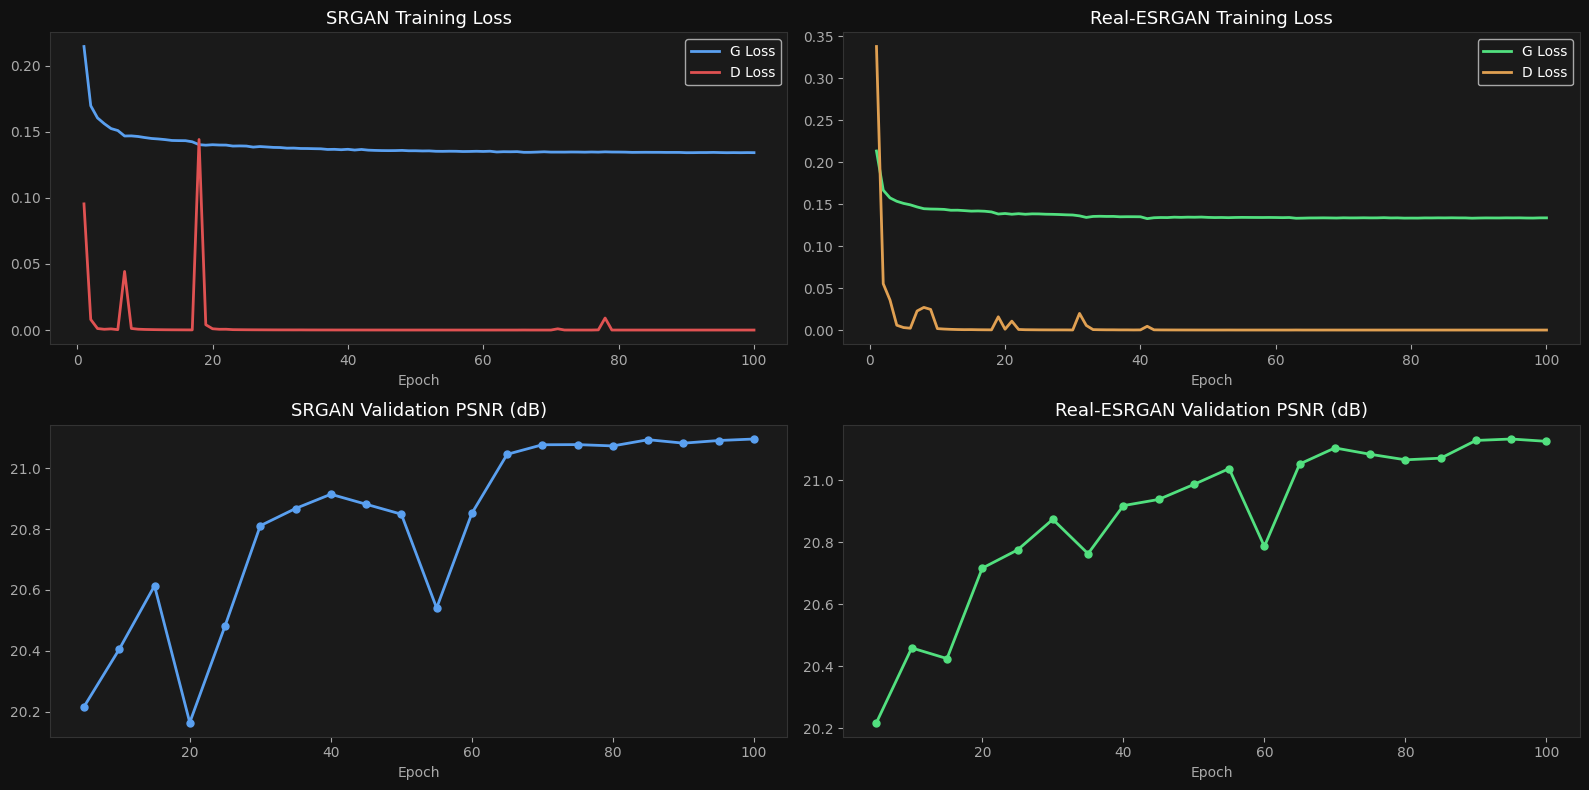

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), facecolor='#111')
epochs_range = range(1, cfg.EPOCHS + 1)

axes[0][0].plot(epochs_range, srgan_train_losses_G, color='#5aa0f0', lw=2, label='G Loss')
axes[0][0].plot(epochs_range, srgan_train_losses_D, color='#e05252', lw=2, label='D Loss')
axes[0][0].set_title('SRGAN Training Loss', color='white', fontsize=13)
axes[0][0].legend(facecolor='#1a1a1a', labelcolor='white')

axes[0][1].plot(epochs_range, esrgan_train_losses_G, color='#52e07f', lw=2, label='G Loss')
axes[0][1].plot(epochs_range, esrgan_train_losses_D, color='#e0a052', lw=2, label='D Loss')
axes[0][1].set_title('Real-ESRGAN Training Loss', color='white', fontsize=13)
axes[0][1].legend(facecolor='#1a1a1a', labelcolor='white')

if srgan_val_psnrs:
    ep_s, ps_s = zip(*srgan_val_psnrs)
    axes[1][0].plot(ep_s, ps_s, color='#5aa0f0', lw=2, marker='o', ms=5)
    axes[1][0].set_title('SRGAN Validation PSNR (dB)', color='white', fontsize=13)

if esrgan_val_psnrs:
    ep_e, ps_e = zip(*esrgan_val_psnrs)
    axes[1][1].plot(ep_e, ps_e, color='#52e07f', lw=2, marker='o', ms=5)
    axes[1][1].set_title('Real-ESRGAN Validation PSNR (dB)', color='white', fontsize=13)

for ax in axes.flatten():
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='#aaa')
    ax.set_xlabel('Epoch', color='#aaa')
    for s in ax.spines.values(): s.set_edgecolor('#333')

plt.tight_layout()
plt.savefig(f'{cfg.SAMPLE_DIR}/training_curves.png', bbox_inches='tight', dpi=120, facecolor='#111')
plt.show()

## 10. Inference & 4-Way Comparison

Loaded SRGAN from epoch 100
Loaded ESRGAN from epoch 95


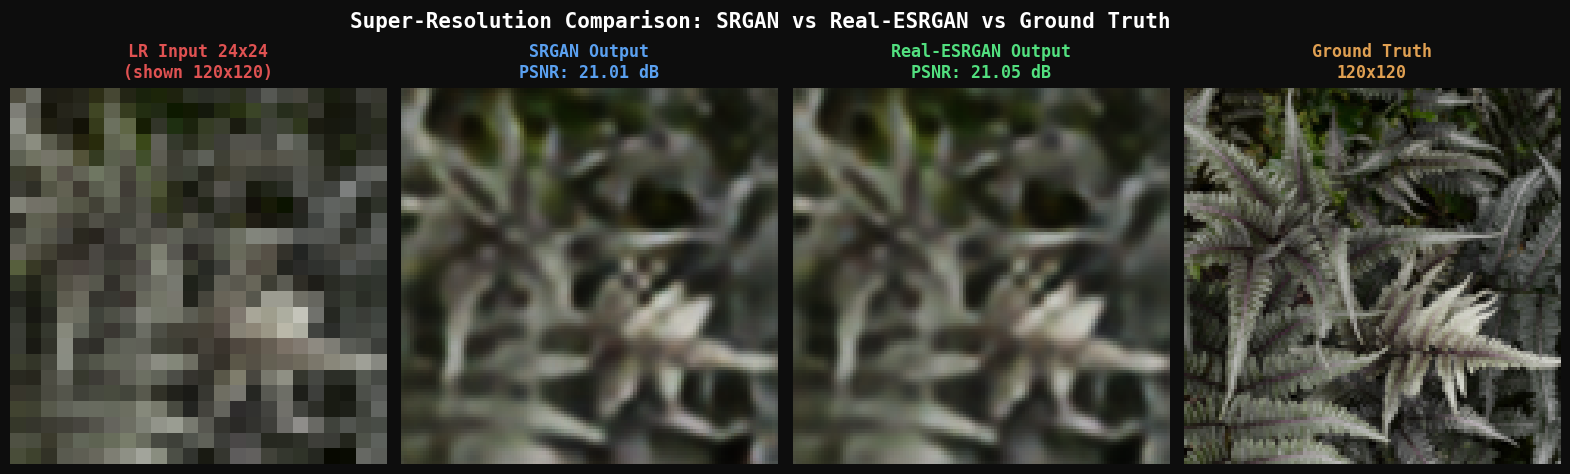

Saved -> /kaggle/working/samples/comparison_result.png
SRGAN  PSNR : 21.01 dB
ESRGAN PSNR : 21.05 dB


In [15]:
def prepare_single_image(image_path, hr_size=128, lr_size=24):
    norm      = T.Normalize([0.5]*3, [0.5]*3)
    to_tensor = T.ToTensor()

    img  = Image.open(image_path).convert('RGB')
    w, h = img.size
    img  = TF.center_crop(img, min(w, h))
    hr   = img.resize((hr_size, hr_size), Image.BICUBIC)
    lr   = hr.resize((lr_size,  lr_size), Image.BICUBIC)
    lr_up = lr.resize((hr_size, hr_size), Image.BICUBIC)

    hr_t    = norm(to_tensor(hr)).unsqueeze(0)
    lr_t    = norm(to_tensor(lr)).unsqueeze(0)
    lr_up_t = norm(to_tensor(lr_up)).unsqueeze(0)
    return hr_t, lr_t, lr_up_t, hr, lr


def show_comparison(image_path,
                    srgan_ckpt=None,
                    esrgan_ckpt=None,
                    hr_size=128,
                    lr_size=24):
    g_srgan  = Generator_SRGAN(scale_factor=hr_size // lr_size).to(DEVICE)
    g_esrgan = Generator_RealESRGAN(scale_factor=hr_size // lr_size).to(DEVICE)

    if srgan_ckpt and os.path.exists(srgan_ckpt):
        ckpt = torch.load(srgan_ckpt, map_location=DEVICE)
        g_srgan.load_state_dict(ckpt['G'])
        print(f'Loaded SRGAN from epoch {ckpt["epoch"]}')

    if esrgan_ckpt and os.path.exists(esrgan_ckpt):
        ckpt = torch.load(esrgan_ckpt, map_location=DEVICE)
        g_esrgan.load_state_dict(ckpt['G'])
        print(f'Loaded ESRGAN from epoch {ckpt["epoch"]}')

    g_srgan.eval()
    g_esrgan.eval()

    hr_t, lr_t, lr_up_t, hr_pil, lr_pil = prepare_single_image(image_path, hr_size, lr_size)
    lr_t    = lr_t.to(DEVICE)
    hr_t    = hr_t.to(DEVICE)
    lr_up_t = lr_up_t.to(DEVICE)

    with torch.no_grad():
        srgan_out  = g_srgan(lr_t)
        esrgan_out = g_esrgan(lr_t)

    psnr_srgan  = psnr(srgan_out,  hr_t).item()
    psnr_esrgan = psnr(esrgan_out, hr_t).item()

    lr_display = lr_pil.resize((hr_size, hr_size), Image.NEAREST)

    panels = [
        (lr_display,              f'LR Input 24x24\n(shown {hr_size}x{hr_size})',     '#e05252'),
        (t2pil(srgan_out),        f'SRGAN Output\nPSNR: {psnr_srgan:.2f} dB',         '#5aa0f0'),
        (t2pil(esrgan_out),       f'Real-ESRGAN Output\nPSNR: {psnr_esrgan:.2f} dB',  '#52e07f'),
        (hr_pil,                  f'Ground Truth\n{hr_size}x{hr_size}',               '#e0a052'),
    ]

    fig = plt.figure(figsize=(20, 5.5), facecolor='#0d0d0d')
    gs  = gridspec.GridSpec(1, 4, wspace=0.04)

    for i, (img, title, color) in enumerate(panels):
        ax = fig.add_subplot(gs[i])
        ax.imshow(np.array(img))
        ax.set_title(title, color=color, fontsize=12, fontweight='bold',
                     fontfamily='monospace', pad=8)
        ax.axis('off')
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_edgecolor(color)
            s.set_linewidth(2.5)

    fig.suptitle('Super-Resolution Comparison: SRGAN vs Real-ESRGAN vs Ground Truth',
                 color='white', fontsize=15, fontweight='bold', fontfamily='monospace')
    plt.tight_layout()
    out_path = f'{cfg.SAMPLE_DIR}/comparison_result.png'
    plt.savefig(out_path, bbox_inches='tight', dpi=150, facecolor='#0d0d0d')
    plt.show()
    print(f'Saved -> {out_path}')
    print(f'SRGAN  PSNR : {psnr_srgan:.2f} dB')
    print(f'ESRGAN PSNR : {psnr_esrgan:.2f} dB')


TEST_IMAGE   = '/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_valid_HR/DIV2K_valid_HR/0840.png'
SRGAN_CKPT   = f'{cfg.SAVE_DIR}/srgan/best.pt'
ESRGAN_CKPT  = f'{cfg.SAVE_DIR}/esrgan/best.pt'

if os.path.exists(TEST_IMAGE):
    show_comparison(
        image_path  = TEST_IMAGE,
        srgan_ckpt  = SRGAN_CKPT,
        esrgan_ckpt = ESRGAN_CKPT,
        hr_size     = cfg.HR_SIZE,
        lr_size     = cfg.LR_SIZE,
    )
else:
    print(f'Set TEST_IMAGE to a valid path. Current: {TEST_IMAGE}')

## 11. Batch Comparison on Validation Set

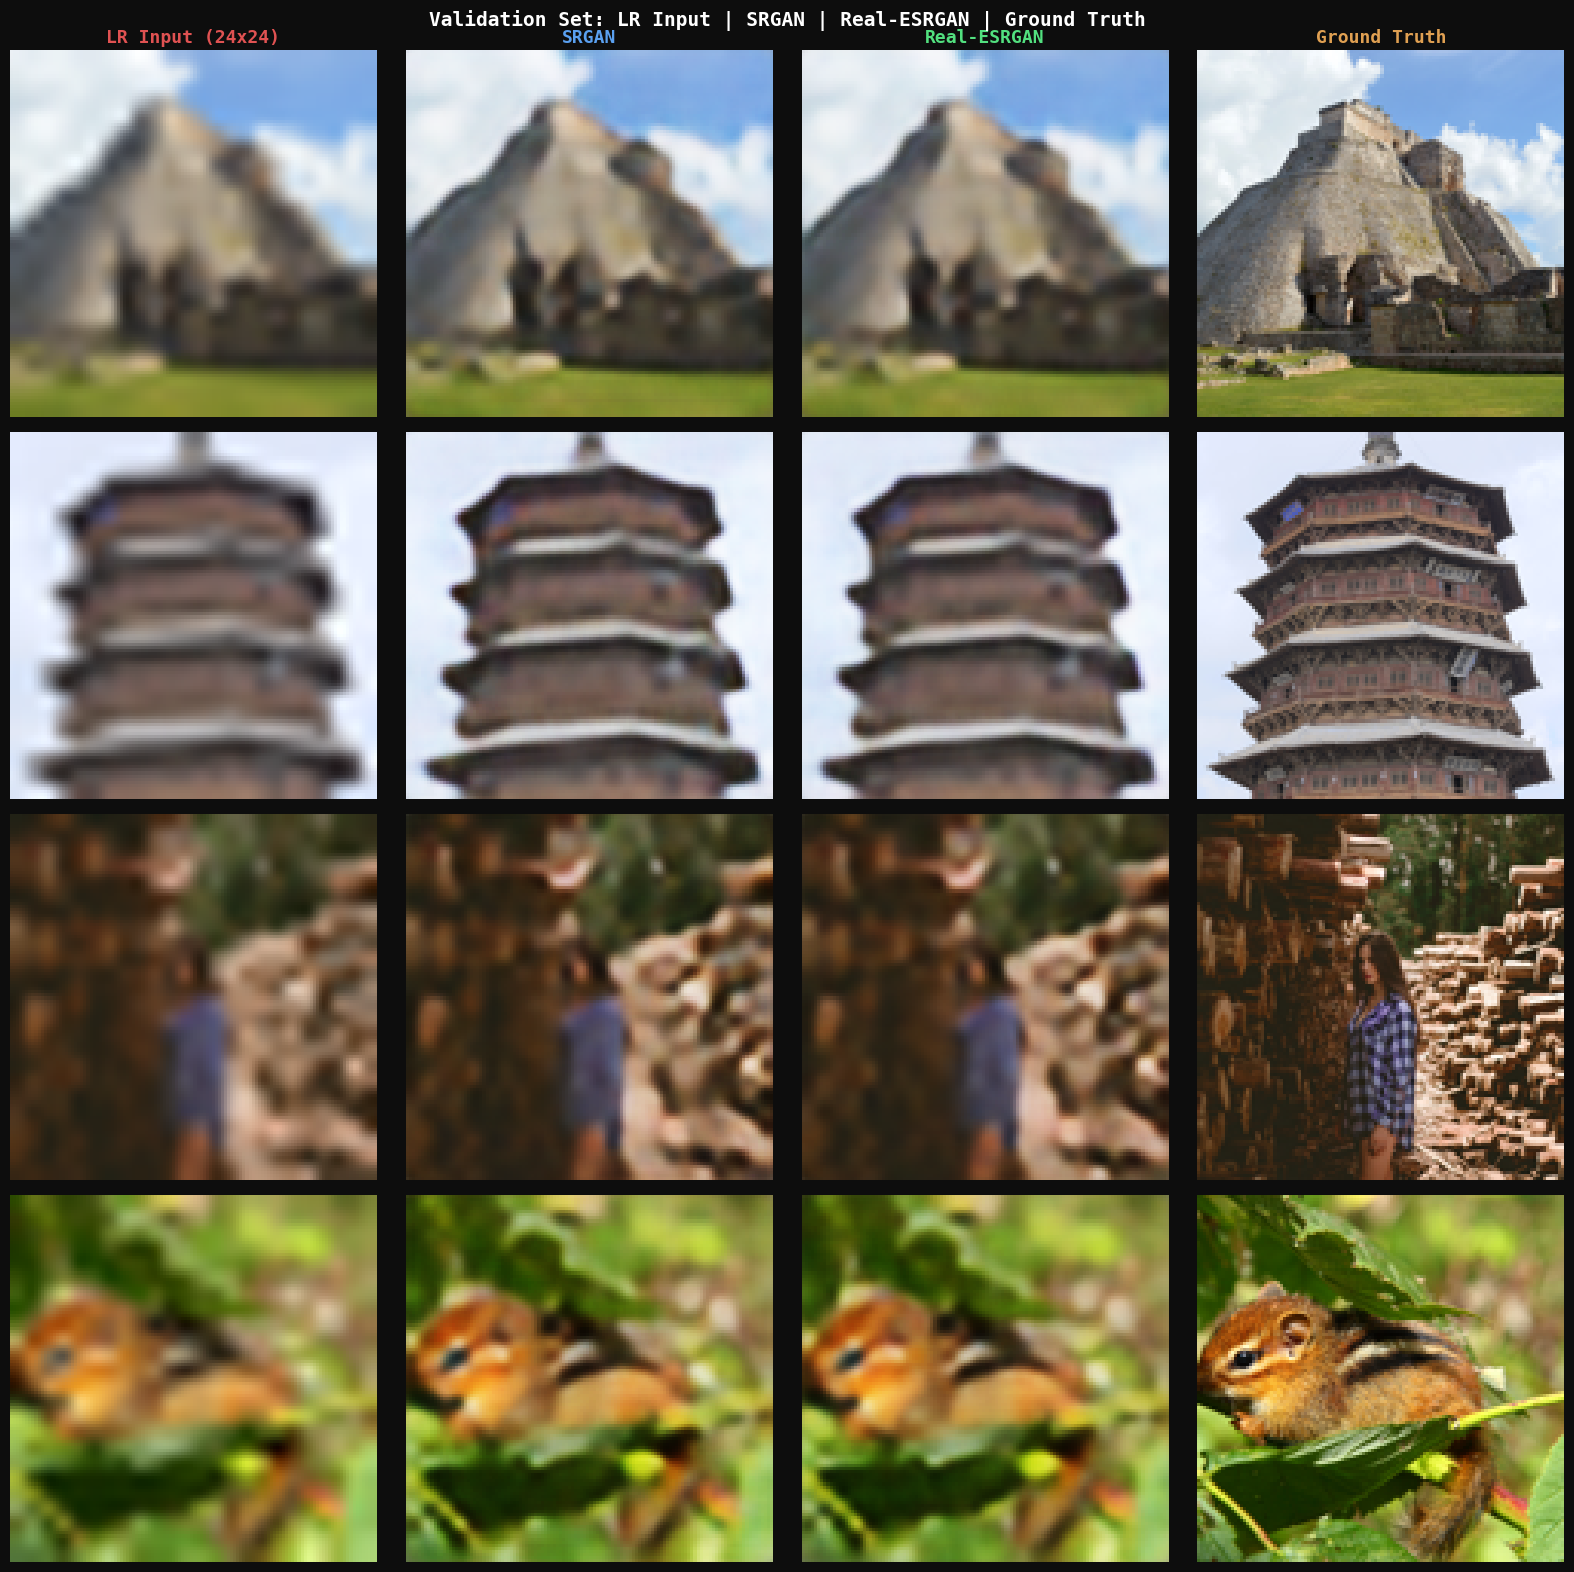

Saved -> /kaggle/working/samples/batch_comparison.png


In [16]:
def batch_comparison(n_images=4):
    g_srgan  = Generator_SRGAN(scale_factor=SCALE_FACTOR).to(DEVICE)
    g_esrgan = Generator_RealESRGAN(scale_factor=SCALE_FACTOR).to(DEVICE)

    if os.path.exists(SRGAN_CKPT):
        ckpt = torch.load(SRGAN_CKPT, map_location=DEVICE)
        g_srgan.load_state_dict(ckpt['G'])

    if os.path.exists(ESRGAN_CKPT):
        ckpt = torch.load(ESRGAN_CKPT, map_location=DEVICE)
        g_esrgan.load_state_dict(ckpt['G'])

    g_srgan.eval()
    g_esrgan.eval()

    vbatch = next(iter(val_dl))
    hr_v   = vbatch['hr'][:n_images].to(DEVICE)
    lr_v   = vbatch['lr'][:n_images].to(DEVICE)
    lr_up_v = vbatch['lr_up'][:n_images].to(DEVICE)

    with torch.no_grad():
        srgan_out  = g_srgan(lr_v)
        esrgan_out = g_esrgan(lr_v)

    fig, axes = plt.subplots(n_images, 4, figsize=(16, 4 * n_images), facecolor='#0d0d0d')
    col_titles = ['LR Input (24x24)', 'SRGAN', 'Real-ESRGAN', 'Ground Truth']
    col_colors = ['#e05252', '#5aa0f0', '#52e07f', '#e0a052']

    tensors_per_col = [lr_up_v, srgan_out, esrgan_out, hr_v]

    for i in range(n_images):
        for j, (col_t, col_title, col_color) in enumerate(zip(tensors_per_col, col_titles, col_colors)):
            ax = axes[i][j]
            img_np = (col_t[i].clamp(-1, 1).permute(1, 2, 0).cpu().numpy() + 1) / 2
            ax.imshow(img_np)
            ax.axis('off')
            if i == 0:
                ax.set_title(col_title, color=col_color, fontsize=13,
                             fontweight='bold', fontfamily='monospace')
            for s in ax.spines.values():
                s.set_visible(True)
                s.set_edgecolor(col_color)
                s.set_linewidth(1.5)

    fig.suptitle(f'Validation Set: LR Input | SRGAN | Real-ESRGAN | Ground Truth',
                 color='white', fontsize=14, fontweight='bold', fontfamily='monospace')
    plt.tight_layout()
    out_path = f'{cfg.SAMPLE_DIR}/batch_comparison.png'
    plt.savefig(out_path, bbox_inches='tight', dpi=130, facecolor='#0d0d0d')
    plt.show()
    print(f'Saved -> {out_path}')


batch_comparison(n_images=4)

## 12. Save Production Models

In [17]:
torch.save({
    'model_state_dict': srgan_G.state_dict(),
    'config': {
        'scale_factor': SCALE_FACTOR,
        'hr_size': cfg.HR_SIZE,
        'lr_size': cfg.LR_SIZE,
    }
}, '/kaggle/working/srgan_model.pth')

torch.save({
    'model_state_dict': esrgan_G.state_dict(),
    'config': {
        'scale_factor': SCALE_FACTOR,
        'hr_size': cfg.HR_SIZE,
        'lr_size': cfg.LR_SIZE,
    }
}, '/kaggle/working/realesrgan_model.pth')

print('SRGAN model saved  -> /kaggle/working/srgan_model.pth')
print('ESRGAN model saved -> /kaggle/working/realesrgan_model.pth')

SRGAN model saved  -> /kaggle/working/srgan_model.pth
ESRGAN model saved -> /kaggle/working/realesrgan_model.pth


Loaded SRGAN from epoch 100
Loaded ESRGAN from epoch 95


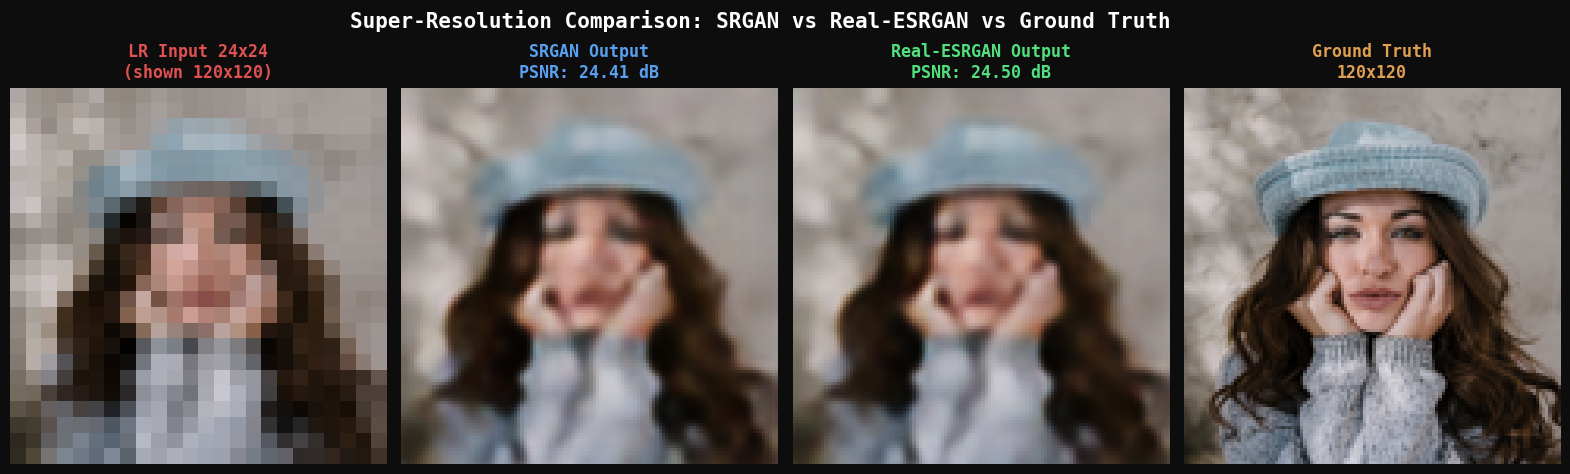

Saved -> /kaggle/working/samples/comparison_result.png
SRGAN  PSNR : 24.41 dB
ESRGAN PSNR : 24.50 dB


In [18]:
def prepare_single_image(image_path, hr_size=128, lr_size=24):
    norm      = T.Normalize([0.5]*3, [0.5]*3)
    to_tensor = T.ToTensor()

    img  = Image.open(image_path).convert('RGB')
    w, h = img.size
    img  = TF.center_crop(img, min(w, h))
    hr   = img.resize((hr_size, hr_size), Image.BICUBIC)
    lr   = hr.resize((lr_size,  lr_size), Image.BICUBIC)
    lr_up = lr.resize((hr_size, hr_size), Image.BICUBIC)

    hr_t    = norm(to_tensor(hr)).unsqueeze(0)
    lr_t    = norm(to_tensor(lr)).unsqueeze(0)
    lr_up_t = norm(to_tensor(lr_up)).unsqueeze(0)
    return hr_t, lr_t, lr_up_t, hr, lr


def show_comparison(image_path,
                    srgan_ckpt=None,
                    esrgan_ckpt=None,
                    hr_size=128,
                    lr_size=24):
    g_srgan  = Generator_SRGAN(scale_factor=hr_size // lr_size).to(DEVICE)
    g_esrgan = Generator_RealESRGAN(scale_factor=hr_size // lr_size).to(DEVICE)

    if srgan_ckpt and os.path.exists(srgan_ckpt):
        ckpt = torch.load(srgan_ckpt, map_location=DEVICE)
        g_srgan.load_state_dict(ckpt['G'])
        print(f'Loaded SRGAN from epoch {ckpt["epoch"]}')

    if esrgan_ckpt and os.path.exists(esrgan_ckpt):
        ckpt = torch.load(esrgan_ckpt, map_location=DEVICE)
        g_esrgan.load_state_dict(ckpt['G'])
        print(f'Loaded ESRGAN from epoch {ckpt["epoch"]}')

    g_srgan.eval()
    g_esrgan.eval()

    hr_t, lr_t, lr_up_t, hr_pil, lr_pil = prepare_single_image(image_path, hr_size, lr_size)
    lr_t    = lr_t.to(DEVICE)
    hr_t    = hr_t.to(DEVICE)
    lr_up_t = lr_up_t.to(DEVICE)

    with torch.no_grad():
        srgan_out  = g_srgan(lr_t)
        esrgan_out = g_esrgan(lr_t)

    psnr_srgan  = psnr(srgan_out,  hr_t).item()
    psnr_esrgan = psnr(esrgan_out, hr_t).item()

    lr_display = lr_pil.resize((hr_size, hr_size), Image.NEAREST)

    panels = [
        (lr_display,              f'LR Input 24x24\n(shown {hr_size}x{hr_size})',     '#e05252'),
        (t2pil(srgan_out),        f'SRGAN Output\nPSNR: {psnr_srgan:.2f} dB',         '#5aa0f0'),
        (t2pil(esrgan_out),       f'Real-ESRGAN Output\nPSNR: {psnr_esrgan:.2f} dB',  '#52e07f'),
        (hr_pil,                  f'Ground Truth\n{hr_size}x{hr_size}',               '#e0a052'),
    ]

    fig = plt.figure(figsize=(20, 5.5), facecolor='#0d0d0d')
    gs  = gridspec.GridSpec(1, 4, wspace=0.04)

    for i, (img, title, color) in enumerate(panels):
        ax = fig.add_subplot(gs[i])
        ax.imshow(np.array(img))
        ax.set_title(title, color=color, fontsize=12, fontweight='bold',
                     fontfamily='monospace', pad=8)
        ax.axis('off')
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_edgecolor(color)
            s.set_linewidth(2.5)

    fig.suptitle('Super-Resolution Comparison: SRGAN vs Real-ESRGAN vs Ground Truth',
                 color='white', fontsize=15, fontweight='bold', fontfamily='monospace')
    plt.tight_layout()
    out_path = f'{cfg.SAMPLE_DIR}/comparison_result.png'
    plt.savefig(out_path, bbox_inches='tight', dpi=150, facecolor='#0d0d0d')
    plt.show()
    print(f'Saved -> {out_path}')
    print(f'SRGAN  PSNR : {psnr_srgan:.2f} dB')
    print(f'ESRGAN PSNR : {psnr_esrgan:.2f} dB')


TEST_IMAGE   = '/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_valid_HR/DIV2K_valid_HR/0855.png'
SRGAN_CKPT   = f'{cfg.SAVE_DIR}/srgan/best.pt'
ESRGAN_CKPT  = f'{cfg.SAVE_DIR}/esrgan/best.pt'

if os.path.exists(TEST_IMAGE):
    show_comparison(
        image_path  = TEST_IMAGE,
        srgan_ckpt  = SRGAN_CKPT,
        esrgan_ckpt = ESRGAN_CKPT,
        hr_size     = cfg.HR_SIZE,
        lr_size     = cfg.LR_SIZE,
    )
else:
    print(f'Set TEST_IMAGE to a valid path. Current: {TEST_IMAGE}')

Loaded SRGAN from epoch 100
Loaded ESRGAN from epoch 95


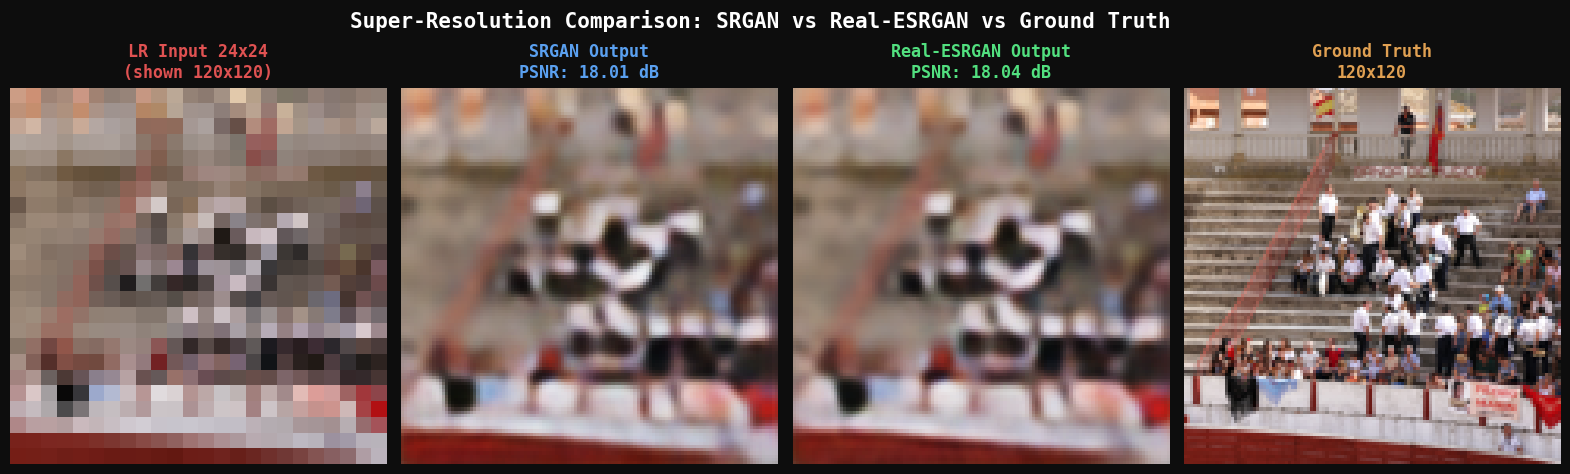

Saved -> /kaggle/working/samples/comparison_result.png
SRGAN  PSNR : 18.01 dB
ESRGAN PSNR : 18.04 dB


In [19]:
def prepare_single_image(image_path, hr_size=128, lr_size=24):
    norm      = T.Normalize([0.5]*3, [0.5]*3)
    to_tensor = T.ToTensor()

    img  = Image.open(image_path).convert('RGB')
    w, h = img.size
    img  = TF.center_crop(img, min(w, h))
    hr   = img.resize((hr_size, hr_size), Image.BICUBIC)
    lr   = hr.resize((lr_size,  lr_size), Image.BICUBIC)
    lr_up = lr.resize((hr_size, hr_size), Image.BICUBIC)

    hr_t    = norm(to_tensor(hr)).unsqueeze(0)
    lr_t    = norm(to_tensor(lr)).unsqueeze(0)
    lr_up_t = norm(to_tensor(lr_up)).unsqueeze(0)
    return hr_t, lr_t, lr_up_t, hr, lr


def show_comparison(image_path,
                    srgan_ckpt=None,
                    esrgan_ckpt=None,
                    hr_size=128,
                    lr_size=24):
    g_srgan  = Generator_SRGAN(scale_factor=hr_size // lr_size).to(DEVICE)
    g_esrgan = Generator_RealESRGAN(scale_factor=hr_size // lr_size).to(DEVICE)

    if srgan_ckpt and os.path.exists(srgan_ckpt):
        ckpt = torch.load(srgan_ckpt, map_location=DEVICE)
        g_srgan.load_state_dict(ckpt['G'])
        print(f'Loaded SRGAN from epoch {ckpt["epoch"]}')

    if esrgan_ckpt and os.path.exists(esrgan_ckpt):
        ckpt = torch.load(esrgan_ckpt, map_location=DEVICE)
        g_esrgan.load_state_dict(ckpt['G'])
        print(f'Loaded ESRGAN from epoch {ckpt["epoch"]}')

    g_srgan.eval()
    g_esrgan.eval()

    hr_t, lr_t, lr_up_t, hr_pil, lr_pil = prepare_single_image(image_path, hr_size, lr_size)
    lr_t    = lr_t.to(DEVICE)
    hr_t    = hr_t.to(DEVICE)
    lr_up_t = lr_up_t.to(DEVICE)

    with torch.no_grad():
        srgan_out  = g_srgan(lr_t)
        esrgan_out = g_esrgan(lr_t)

    psnr_srgan  = psnr(srgan_out,  hr_t).item()
    psnr_esrgan = psnr(esrgan_out, hr_t).item()

    lr_display = lr_pil.resize((hr_size, hr_size), Image.NEAREST)

    panels = [
        (lr_display,              f'LR Input 24x24\n(shown {hr_size}x{hr_size})',     '#e05252'),
        (t2pil(srgan_out),        f'SRGAN Output\nPSNR: {psnr_srgan:.2f} dB',         '#5aa0f0'),
        (t2pil(esrgan_out),       f'Real-ESRGAN Output\nPSNR: {psnr_esrgan:.2f} dB',  '#52e07f'),
        (hr_pil,                  f'Ground Truth\n{hr_size}x{hr_size}',               '#e0a052'),
    ]

    fig = plt.figure(figsize=(20, 5.5), facecolor='#0d0d0d')
    gs  = gridspec.GridSpec(1, 4, wspace=0.04)

    for i, (img, title, color) in enumerate(panels):
        ax = fig.add_subplot(gs[i])
        ax.imshow(np.array(img))
        ax.set_title(title, color=color, fontsize=12, fontweight='bold',
                     fontfamily='monospace', pad=8)
        ax.axis('off')
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_edgecolor(color)
            s.set_linewidth(2.5)

    fig.suptitle('Super-Resolution Comparison: SRGAN vs Real-ESRGAN vs Ground Truth',
                 color='white', fontsize=15, fontweight='bold', fontfamily='monospace')
    plt.tight_layout()
    out_path = f'{cfg.SAMPLE_DIR}/comparison_result.png'
    plt.savefig(out_path, bbox_inches='tight', dpi=150, facecolor='#0d0d0d')
    plt.show()
    print(f'Saved -> {out_path}')
    print(f'SRGAN  PSNR : {psnr_srgan:.2f} dB')
    print(f'ESRGAN PSNR : {psnr_esrgan:.2f} dB')


TEST_IMAGE   = '/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_valid_HR/DIV2K_valid_HR/0825.png'
SRGAN_CKPT   = f'{cfg.SAVE_DIR}/srgan/best.pt'
ESRGAN_CKPT  = f'{cfg.SAVE_DIR}/esrgan/best.pt'

if os.path.exists(TEST_IMAGE):
    show_comparison(
        image_path  = TEST_IMAGE,
        srgan_ckpt  = SRGAN_CKPT,
        esrgan_ckpt = ESRGAN_CKPT,
        hr_size     = cfg.HR_SIZE,
        lr_size     = cfg.LR_SIZE,
    )
else:
    print(f'Set TEST_IMAGE to a valid path. Current: {TEST_IMAGE}')

Loaded SRGAN from epoch 100
Loaded ESRGAN from epoch 95


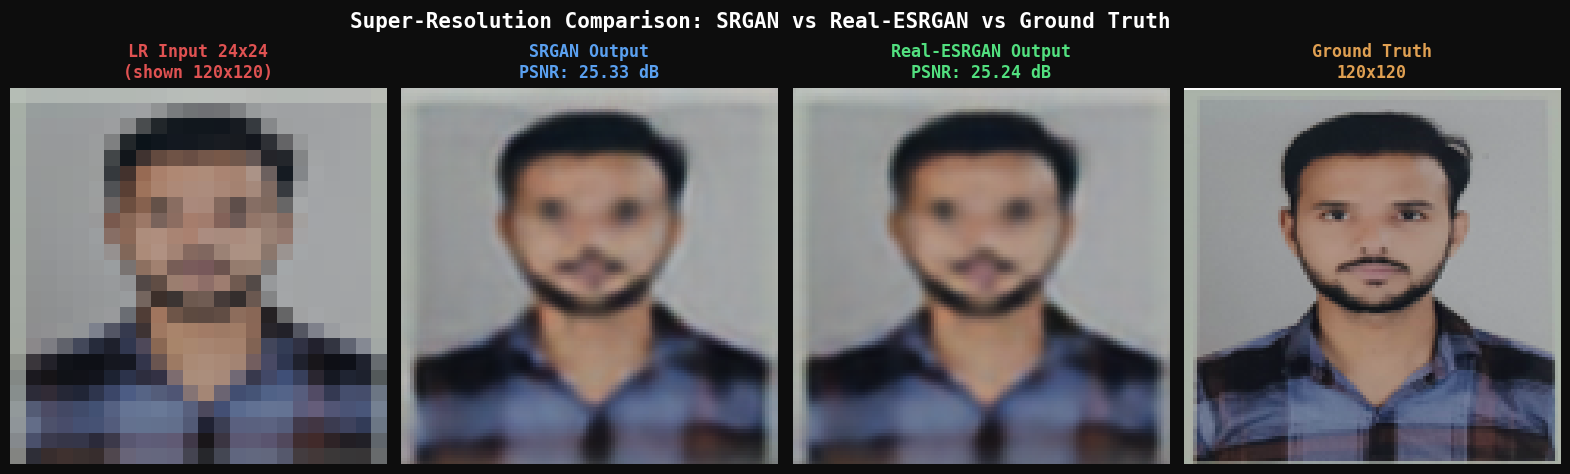

Saved -> /kaggle/working/samples/comparison_result.png
SRGAN  PSNR : 25.33 dB
ESRGAN PSNR : 25.24 dB


In [20]:
def prepare_single_image(image_path, hr_size=128, lr_size=24):
    norm      = T.Normalize([0.5]*3, [0.5]*3)
    to_tensor = T.ToTensor()

    img  = Image.open(image_path).convert('RGB')
    w, h = img.size
    img  = TF.center_crop(img, min(w, h))
    hr   = img.resize((hr_size, hr_size), Image.BICUBIC)
    lr   = hr.resize((lr_size,  lr_size), Image.BICUBIC)
    lr_up = lr.resize((hr_size, hr_size), Image.BICUBIC)

    hr_t    = norm(to_tensor(hr)).unsqueeze(0)
    lr_t    = norm(to_tensor(lr)).unsqueeze(0)
    lr_up_t = norm(to_tensor(lr_up)).unsqueeze(0)
    return hr_t, lr_t, lr_up_t, hr, lr


def show_comparison(image_path,
                    srgan_ckpt=None,
                    esrgan_ckpt=None,
                    hr_size=128,
                    lr_size=24):
    g_srgan  = Generator_SRGAN(scale_factor=hr_size // lr_size).to(DEVICE)
    g_esrgan = Generator_RealESRGAN(scale_factor=hr_size // lr_size).to(DEVICE)

    if srgan_ckpt and os.path.exists(srgan_ckpt):
        ckpt = torch.load(srgan_ckpt, map_location=DEVICE)
        g_srgan.load_state_dict(ckpt['G'])
        print(f'Loaded SRGAN from epoch {ckpt["epoch"]}')

    if esrgan_ckpt and os.path.exists(esrgan_ckpt):
        ckpt = torch.load(esrgan_ckpt, map_location=DEVICE)
        g_esrgan.load_state_dict(ckpt['G'])
        print(f'Loaded ESRGAN from epoch {ckpt["epoch"]}')

    g_srgan.eval()
    g_esrgan.eval()

    hr_t, lr_t, lr_up_t, hr_pil, lr_pil = prepare_single_image(image_path, hr_size, lr_size)
    lr_t    = lr_t.to(DEVICE)
    hr_t    = hr_t.to(DEVICE)
    lr_up_t = lr_up_t.to(DEVICE)

    with torch.no_grad():
        srgan_out  = g_srgan(lr_t)
        esrgan_out = g_esrgan(lr_t)

    psnr_srgan  = psnr(srgan_out,  hr_t).item()
    psnr_esrgan = psnr(esrgan_out, hr_t).item()

    lr_display = lr_pil.resize((hr_size, hr_size), Image.NEAREST)

    panels = [
        (lr_display,              f'LR Input 24x24\n(shown {hr_size}x{hr_size})',     '#e05252'),
        (t2pil(srgan_out),        f'SRGAN Output\nPSNR: {psnr_srgan:.2f} dB',         '#5aa0f0'),
        (t2pil(esrgan_out),       f'Real-ESRGAN Output\nPSNR: {psnr_esrgan:.2f} dB',  '#52e07f'),
        (hr_pil,                  f'Ground Truth\n{hr_size}x{hr_size}',               '#e0a052'),
    ]

    fig = plt.figure(figsize=(20, 5.5), facecolor='#0d0d0d')
    gs  = gridspec.GridSpec(1, 4, wspace=0.04)

    for i, (img, title, color) in enumerate(panels):
        ax = fig.add_subplot(gs[i])
        ax.imshow(np.array(img))
        ax.set_title(title, color=color, fontsize=12, fontweight='bold',
                     fontfamily='monospace', pad=8)
        ax.axis('off')
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_edgecolor(color)
            s.set_linewidth(2.5)

    fig.suptitle('Super-Resolution Comparison: SRGAN vs Real-ESRGAN vs Ground Truth',
                 color='white', fontsize=15, fontweight='bold', fontfamily='monospace')
    plt.tight_layout()
    out_path = f'{cfg.SAMPLE_DIR}/comparison_result.png'
    plt.savefig(out_path, bbox_inches='tight', dpi=150, facecolor='#0d0d0d')
    plt.show()
    print(f'Saved -> {out_path}')
    print(f'SRGAN  PSNR : {psnr_srgan:.2f} dB')
    print(f'ESRGAN PSNR : {psnr_esrgan:.2f} dB')


TEST_IMAGE   = '/kaggle/input/datasets/rohit20sharma/dataset/imresizer-Screenshot 2024-08-21 172726.png'
SRGAN_CKPT   = f'{cfg.SAVE_DIR}/srgan/best.pt'
ESRGAN_CKPT  = f'{cfg.SAVE_DIR}/esrgan/best.pt'

if os.path.exists(TEST_IMAGE):
    show_comparison(
        image_path  = TEST_IMAGE,
        srgan_ckpt  = SRGAN_CKPT,
        esrgan_ckpt = ESRGAN_CKPT,
        hr_size     = cfg.HR_SIZE,
        lr_size     = cfg.LR_SIZE,
    )
else:
    print(f'Set TEST_IMAGE to a valid path. Current: {TEST_IMAGE}')